In [1]:
# Load necessary libraries
library(tidyverse)  # for data manipulation and visualization
library(car)        # for regression diagnostics
library(broom)      # for tidy model outputs
library(ggplot2)


library(readr)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: carData




Attaching package: ‘car’




The following object is masked from ‘package:dplyr’:

    recode




The following object is masked from ‘package:purrr’:

    some




In [2]:
smsa <- read.csv("/kaggle/input/datasets/josephw00tfeu/lin-mod-dataset-fa3/smsa.csv")
head(smsa)

,City,Mort,Edu,Nwt,Jant,Rain,Nox,Hum,Inc
,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>
1,"Akron, OH",921.87,11.4,8.8,27,36,2.71,59,29.560
2,"Albany-Schenectady-Troy, NY",997.87,11.0,3.5,23,35,2.30,57,31.458
3,"Allentown, Bethlehem, PA-NJ",962.35,9.8,0.8,29,44,1.79,54,31.856
4,"Atlanta, GA",982.29,11.1,27.1,45,47,2.08,56,32.452
5,"Baltimore, MD",1071.29,9.6,24.4,35,43,3.64,55,32.368
6,"Birmingham, AL",1030.38,10.2,38.5,45,53,3.47,54,27.835


In [3]:
model_smsa <- lm(Mort ~ Edu + Nwt + Jant + Rain + Nox + Hum + Inc, data = smsa)
summary(model_smsa)


Call:
lm(formula = Mort ~ Edu + Nwt + Jant + Rain + Nox + Hum + Inc, 
    data = smsa)

Residuals:
    Min      1Q  Median      3Q     Max 
-84.380 -22.118   2.907  23.154  77.369 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1006.2441    95.0827  10.583 3.84e-14 ***
Edu          -15.3459     7.2515  -2.116  0.03954 *  
Nwt            4.2140     0.6850   6.152 1.47e-07 ***
Jant          -2.1500     0.6593  -3.261  0.00204 ** 
Rain           1.6238     0.5643   2.878  0.00596 ** 
Nox           18.5481     5.5065   3.368  0.00150 ** 
Hum            0.5371     0.9024   0.595  0.55451    
Inc           -0.3453     1.3038  -0.265  0.79227    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 35.48 on 48 degrees of freedom
Multiple R-squared:  0.7137,	Adjusted R-squared:  0.6719 
F-statistic: 17.09 on 7 and 48 DF,  p-value: 4.183e-11


A.)  
67% of the variation in Mortality is explain by our predictors in the model. 

Our model currently is: Mortality = 1006.24 + (-15.35Edu) + (4.21Nwt) + (-2.15Jant) + (1.62Rain) + (18.55Nox) + (0.54Hum) + (-0.35Inc).  
so for each 1 point in our 7 predictor we get in order a  -15.35 decrease, 4.21 increase, -2.15 decrease, 1.62 increase, 18.55 increase, 0.54 increased, and 0.35 decreased in Mortality

In [4]:
model_smsa_HI <- lm(Mort ~ Edu + Nwt + Jant + Rain + Nox, data = smsa)
anova(model_smsa_HI, model_smsa)
summary(model_smsa_HI)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,50,60948.49,NA,NA,NA,NA
2,48,60416.59,2,531.903,0.2112941,0.8102848



Call:
lm(formula = Mort ~ Edu + Nwt + Jant + Rain + Nox, data = smsa)

Residuals:
    Min      1Q  Median      3Q     Max 
-86.139 -24.728   4.088  21.200  79.659 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1028.2323    84.9148  12.109  < 2e-16 ***
Edu          -15.5887     6.4460  -2.418  0.01927 *  
Nwt            4.1807     0.6600   6.334  6.6e-08 ***
Jant          -2.1313     0.6369  -3.347  0.00156 ** 
Rain           1.6331     0.5551   2.942  0.00493 ** 
Nox           18.4132     5.2926   3.479  0.00105 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 34.91 on 50 degrees of freedom
Multiple R-squared:  0.7111,	Adjusted R-squared:  0.6822 
F-statistic: 24.62 on 5 and 50 DF,  p-value: 2.044e-12


B.)   
Based from the Nested Modeling in Anova we can see that the P value is 0.81 and its greater than 0.05 thus the two predictors of Hum and Inc doesn not provide statistically significant effect in our model and thus we should keep our less complex model.  

C.)  
We can see that our individual t-test in the less complex model have more significance and all of our predictors have less than 0.05 p values and in order:   
Edu: 0.019 the least significant  
Nwt: 6.6e-08 very significant  
Jant: 0.0016  
Rain: 0.0049  
Nox:  0.0011  

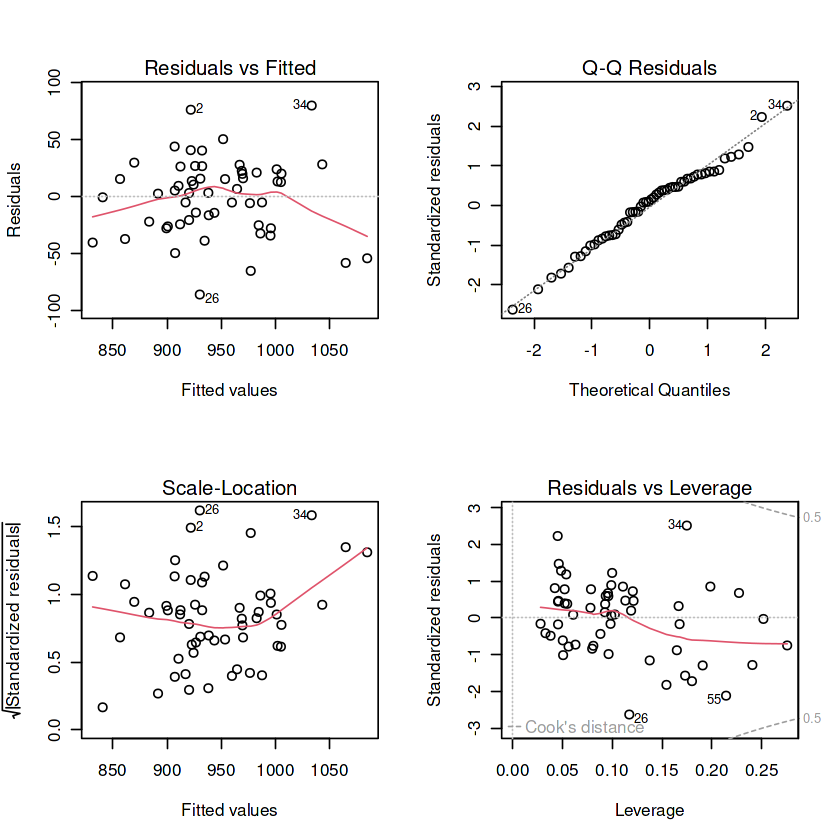

In [5]:
par(mfrow = c(2,2))
plot(model_smsa_HI)

D.)  
Residuals and Fitted : the red line fits is dome shaped and curved and might suggest a non-linear relationship. 

QQ plot: most points are within the center of the line but the ends of the data are moving away might be suggest the data is more varied at lowe and higher values. 

Scale-Location: It mostly shows a cloud shaped data points but the red line indicates a variance in lower and higher end like qq plot. 

Residuals and Leverage: nothing is majorly off the redline and that means no major outlier is affecting our dataset. 

In [6]:
summary(model_smsa_HI)
confint(model_smsa_HI)


Call:
lm(formula = Mort ~ Edu + Nwt + Jant + Rain + Nox, data = smsa)

Residuals:
    Min      1Q  Median      3Q     Max 
-86.139 -24.728   4.088  21.200  79.659 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1028.2323    84.9148  12.109  < 2e-16 ***
Edu          -15.5887     6.4460  -2.418  0.01927 *  
Nwt            4.1807     0.6600   6.334  6.6e-08 ***
Jant          -2.1313     0.6369  -3.347  0.00156 ** 
Rain           1.6331     0.5551   2.942  0.00493 ** 
Nox           18.4132     5.2926   3.479  0.00105 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 34.91 on 50 degrees of freedom
Multiple R-squared:  0.7111,	Adjusted R-squared:  0.6822 
F-statistic: 24.62 on 5 and 50 DF,  p-value: 2.044e-12


,2.5 %,97.5 %
(Intercept),857.6759564,1198.7887074
Edu,-28.5358359,-2.6416409
Nwt,2.8549979,5.5064591
Jant,-3.4104920,-0.8521848
Rain,0.5181088,2.7480796
Nox,7.7827818,29.0436693


E.)  
68% of the variation in Mortality is explain by our simpler predictors in the model. 


Our model currently is: Mortality = 1028.23 + (-15.59Edu) + (4.18Nwt) + (-2.13Jant) + (1.63Rain) + (18.41Nox).  
so for each 1 point in our 5 predictors now we get in order a  -15.59 decrease, 4.18 increase, -2.13 decrease, 1.63 increase, 18.41 increase in Mortality.

The Education and January temperature having negative slope and means it lessens the mortality rates fits the idea of common sense and having more knowledge helps your to survive and learn about pollution.  
The other values of being non negative is a more scientific value and explanation for pollutions and how it increases due to general output of pollution and thus affects our Mortality rate due to pollution. 

Our confidence interval for the new and simpler model fits in with how we got our estimated least squares and how the interval is the lower and upper bounds of the predictors coefficients. 

F.)  
Our R^2 has lowered a bit 71.37% to 71.11 but still falls in line of 71% but in MLR we usually use Adjusted R^2 because it has less affected numbers due to difference in predictors and more stable number.  
Our Adjusted R^2 increased and we explained more variability in the Mortality with less complex model from 67.19% to 68.22% which is good and indicated we are heading to the right direction in the less complex model. 

In [7]:
Edu <- 10
Nwt <- 15
Jant <-  35
Rain <- 40
Nox <- 2
Mortality <- 1028.23 + (-15.59*Edu) + (4.18*Nwt) + (-2.13*Jant) + (1.63*Rain) + (18.41*Nox)
Mortality

[1] 962.5

G.)  Given the following characteristics and values of the predictors with our coefficients from the model we have 962.5 age adjusted Mortality per 100,000 population meaning 962.5 people die on average per 100k population

In [8]:
movies <- read.csv("/kaggle/input/datasets/josephw00tfeu/lin-mod-dataset-fa3/movies.csv")
head(movies)

,Movie,Box,Rate,User,Meta,Len,Win,Nom
,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>
1,Star Wars: Episode IV - A New Hope (1977),460.9357,8.8,423.838,91,121,36,22
2,Toy Story 3 (2010),414.9845,8.5,201.748,92,103,35,41
3,Spider-Man 2 (2004),373.3779,7.5,191.179,83,127,15,39
4,Finding Nemo (2003),339.7144,8.1,263.202,89,100,35,36
5,The Lion King (1994),328.4230,8.3,233.977,83,89,27,22
6,Pirates of the Caribbean: The Curse of the Black Pearl (2003),305.3887,8.0,355.801,63,143,28,74


In [9]:
model_movies <- lm(Box ~ Rate + User + Meta + Len + Win + Nom, data = movies)
summary(model_movies)


Call:
lm(formula = Box ~ Rate + User + Meta + Len + Win + Nom, data = movies)

Residuals:
    Min      1Q  Median      3Q     Max 
-53.161 -22.013  -3.864   9.517  84.574 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept) -172.28110  106.51894  -1.617   0.1232  
Rate          35.34769   22.44744   1.575   0.1327  
User           0.38894    0.19304   2.015   0.0591 .
Meta           1.25615    0.89110   1.410   0.1757  
Len            0.02473    0.54429   0.045   0.9643  
Win           -0.02080    1.33384  -0.016   0.9877  
Nom            0.37261    0.87286   0.427   0.6745  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 42.45 on 18 degrees of freedom
Multiple R-squared:  0.8854,	Adjusted R-squared:  0.8472 
F-statistic: 23.18 on 6 and 18 DF,  p-value: 1.505e-07


A.)  
84% of the variation in Box office receipts is explained by our predictors in the model.  

Our model currently is: Box = -172.28 + (35.35Rate) + (0.39User) + (1.26Meta) + (0.025Len) + (-0.021Win) + (0.37Nom).   
So for each 1 point in our 6 predictors now we get in order a  35.35 increase, 0.39 increase, 1.26 increase, 0.025 increase, -0.021 decreased and 0.37 increased in Box office receipts.   
The R^2 is 88.54% while adjusted R^2 is 84.72% which is similar but for mlr adjusted r^2 is preferred for more stability in the values. 

In [10]:
model_movies_LWN <- lm(Box ~ Rate + User + Meta, data = movies)
summary(model_movies_LWN)


Call:
lm(formula = Box ~ Rate + User + Meta, data = movies)

Residuals:
    Min      1Q  Median      3Q     Max 
-49.202 -22.749  -3.598   7.266  90.059 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept) -169.0862    92.0925  -1.836  0.08055 . 
Rate          35.4962    18.9956   1.869  0.07569 . 
User           0.4328     0.1472   2.940  0.00783 **
Meta           1.2462     0.8047   1.549  0.13640   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 39.53 on 21 degrees of freedom
Multiple R-squared:  0.8841,	Adjusted R-squared:  0.8675 
F-statistic: 53.37 on 3 and 21 DF,  p-value: 5.35e-10


B.)    
86% of the variation in Box office receipts is explained by our predictors in the model.  

Our model currently is: Box = -169.09 + (35.49Rate) + (0.43User) + (1.24Meta).   
So for each 1 point in our 3 predictors now we get in order a  35.49 increase, 0.43 increase, and 1.24 increase in Box office receipts.   
The R^2 is 88.41% while adjusted R^2 is 86.75% which is similar but for mlr adjusted r^2.   
the Adjusted R^2 increased and thus explain more variability in Box office and our more simpler model is better and we should keep

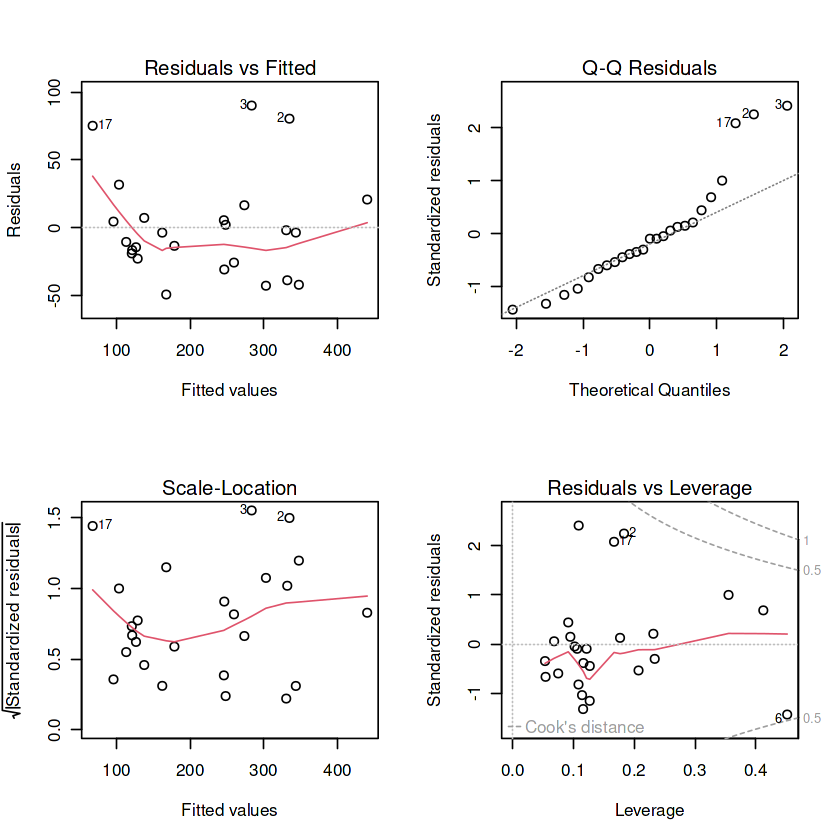

In [11]:
par(mfrow = c(2,2))
plot(model_movies_LWN)

C.)  
Residuals and Fitted : the red line fits is straight shaped but at both ends increased. 

QQ plot: most points are within the center of the line but the ends of the data are moving away very hight might be suggest the data is more varied higher values. 

Scale-Location: It mostly shows a cloud shaped data points but the red line indicates a dip or curved shaped in the middle meaning less points in the upper middle data values. 

Residuals and Leverage: nothing is majorly off the redline and that means no major outlier is affecting our dataset via cooks distance. 

In [12]:
anova(model_movies_LWN, model_movies)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,21,32822.96,NA,NA,NA,NA
2,18,32435.31,3,387.6554,0.0717099,0.9743556


D.)  
the P value is 0.97 and its greater than 0.05 thus the three predictors of Len, Win, and Nom doesn not provide statistically significant effect in our model and thus we should keep our less complex model.  
E.)
our RSE on 6 variables is 42.45 and the 3 variables is 39.53 and thus our simpler models has less errors and provides better data to our model.  
The Adjusted R^2 increased from 84.72% to 86.75 and thus explain more variability in Box office and our more simpler model is better at handling errors and give more explanability to our model

In [13]:
confint(model_movies_LWN)

,2.5 %,97.5 %
(Intercept),-360.6030529,22.4306658
Rate,-4.0072718,74.9995732
User,0.1266152,0.7390223
Meta,-0.4272789,2.9197596


F.)  
Our confidence interval for the new and simpler model fits in with how we got our estimated least squares and how the interval is the lower and upper bounds of the predictors coefficients.  
Intercept: -169.09
Coefficient:  
Rate: 35.49    
User: 0.43  
Meta: 1.24   
This values are all within the interval confidence interval given at worst and best values and thus    
Rate has large bounds from negative to positive and crosses 0 and might suggest more data is needed to lower it or remove because a 0 indicates that it might not be statistically significant and have a non-linear relationship.    
User is the most consistent affect only positive bounds and narrow indicate good data and confidence of the values we get from the model.   
Meta is similar to User but has crosses 0 and might indicate its not statistically significant and have a non-linear relationship.  

In [14]:
Rate <- 9.1
User <- 400
Meta <-  73
Box_Office <- -169.09 + (35.49*Rate) + (0.43*User) + (1.24*Meta)
Box_Office

[1] 416.389

G.)  Given the following characteristics and values of the predictors with our coefficients from the model we have 416.39 all-time US Box Office Receipts in Millions meaning 416.39 millions dollars is generated based from our model on all-time Us Box Office Receipts